In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical
from keras.models import Model,Sequential, Input, load_model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.applications import DenseNet121

ImportError: ignored

In [ ]:
defect_types = ['Center','Donut','Edge-loc','Edge-ring','Loc','Random','Scratch','Near-Full','None']
data_dir = '../input/wafermap/WaferMap/balanced/'
train_dir = os.path.join(data_dir)
#test_dir = os.path.join(data_dir, 'test')

In [ ]:
train_data = []
for defects_id, sp in enumerate(defect_types):
    for file in os.listdir(os.path.join(train_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])
        
train = pd.DataFrame(train_data, columns=['File', 'DefectsId','Defect Type'])
train.head()

,File,DefectsId,Defect Type
0,Center/center_79.jpg,0,Center
1,Center/center_4.jpg,0,Center
2,Center/center_74.jpg,0,Center
3,Center/center_262.jpg,0,Center
4,Center/center_102.jpg,0,Center


In [ ]:
# Randomize the order of training set
SEED = 42
train = train.sample(frac=1, random_state=SEED) 
train.index = np.arange(len(train)) # Reset indices
train.head()

,File,DefectsId,Defect Type
0,Edge-loc/Edge-loc_39.jpg,2,Edge-loc
1,Scratch/Scratch_45.jpg,6,Scratch
2,Random/Random_272.jpg,5,Random
3,Loc/Loc_263.jpg,4,Loc
4,Scratch/Scratch_14.jpg,6,Scratch


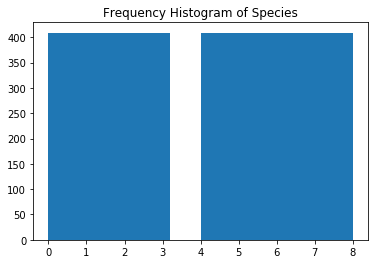

<Figure size 864x864 with 0 Axes>

In [ ]:
# Plot a histogram
plt.hist(train['DefectsId'])
plt.title('Frequency Histogram of Species')
plt.figure(figsize=(12, 12))
plt.show()

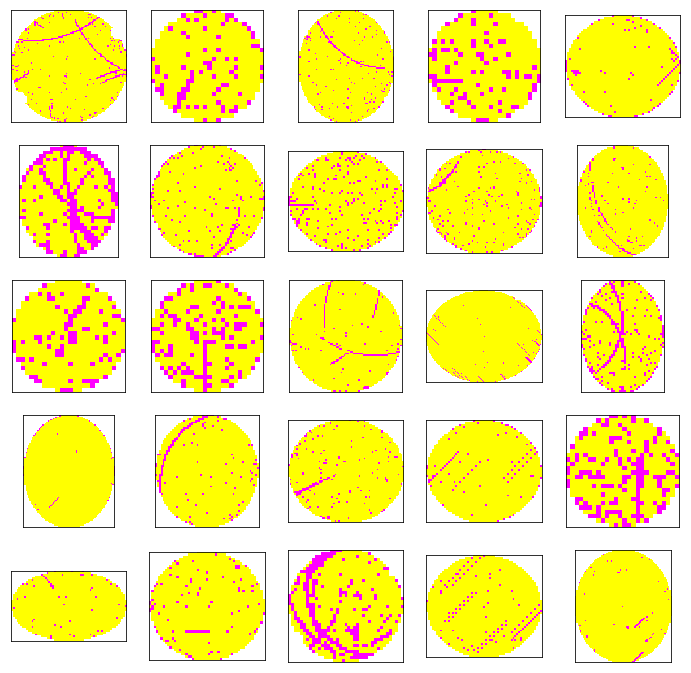

In [ ]:
# Display images for different species
def plot_defects(defect_types, rows, cols):
    fig, ax = plt.subplots(rows, cols, figsize=(12, 12))
    defect_files = train['File'][train['Defect Type'] == defect_types].values
    n = 0
    for i in range(rows):
        for j in range(cols):
            image_path = os.path.join(data_dir, defect_files[n])
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            ax[i, j].imshow(cv2.imread(image_path))
            n += 1
# Displays first n images of class from training set
plot_defects('Scratch', 5, 5)

In [ ]:
IMAGE_SIZE = 64

def read_image(filepath):
    return cv2.imread(os.path.join(data_dir, filepath)) # Loading a color image is the default flag
# Resize image to target size
def resize_image(image, image_size):
    return cv2.resize(image.copy(), image_size, interpolation=cv2.INTER_AREA)

In [ ]:
X_train = np.zeros((train.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))
for i, file in tqdm(enumerate(train['File'].values)):
    image = read_image(file)
    X_train[i] = resize_image(image, (IMAGE_SIZE, IMAGE_SIZE))
# Normalize the data
X_train = X_train / 255.
print('Train Shape: {}'.format(X_train.shape))

3681it [00:09, 374.71it/s]


Train Shape: (3681, 64, 64, 3)


In [ ]:
Y_train = train['DefectsId'].values
Y_train = to_categorical(Y_train, num_classes=9)

In [ ]:
BATCH_SIZE = 64

# Split the train and validation sets 
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=SEED)

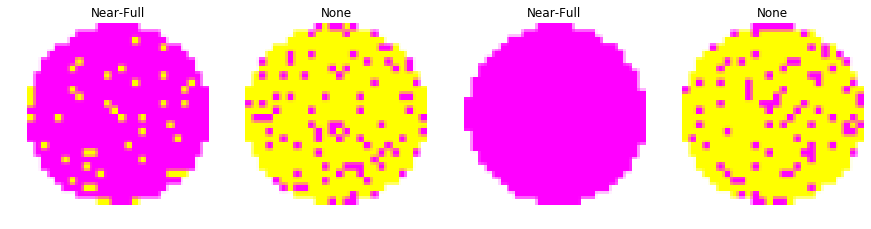

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(15, 15))
for i in range(4):
    ax[i].set_axis_off()
    ax[i].imshow(X_train[i])
    ax[i].set_title(defect_types[np.argmax(Y_train[i])])

In [ ]:
#def construct_model():
    #model = Sequential()
    
    #model.add(Conv2D(filters=32, kernel_size=(5, 5), padding='SAME', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                #activation='relu'))
    #model.add(BatchNormalization()) # Normalize the activations of the previous layer at each batch
    #model.add(Conv2D(filters=32, kernel_size=(5, 5), padding='SAME', activation='relu'))
    #model.add(BatchNormalization())
    #model.add(MaxPool2D(pool_size=(2, 2)))

    #model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='SAME', activation='relu'))
    #model.add(BatchNormalization())
    #model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='SAME', activation='relu'))
    #model.add(BatchNormalization())
    #model.add(MaxPool2D(pool_size=(2, 2)))

    #model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='SAME', activation='relu'))
    #model.add(BatchNormalization())
    #model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='SAME', activation='relu'))
    #model.add(BatchNormalization())
    #model.add(MaxPool2D(pool_size=(2, 2)))

    #model.add(Flatten()) # Flatten the input
    #model.add(Dense(64, activation='relu'))
    #model.add(Dropout(0.2))
    #model.add(Dense(9, activation='softmax'))
    # Configure the learning process
    # The loss function is the objective that the model will try to minimize
    # For any classification problem, use accuracy metric
    #optimizer = Adam(lr=0.002, beta_1=0.9, beta_2=0.999, epsilon=0.1, decay=0.0)
    #model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    #model.summary()
    #return model

In [ ]:
EPOCHS = 50
SIZE=64
N_ch=3

In [ ]:
def build_densenet():
    densenet = DenseNet121(weights='imagenet', include_top=False)

    input = Input(shape=(SIZE, SIZE, N_ch))
    x = Conv2D(3, (3, 3), padding='same')(input)
    
    x = densenet(x)
    
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # multi output
    output = Dense(9,activation = 'softmax', name='root')(x)
 

    # model
    model = Model(input,output)
    
    optimizer = Adam(lr=0.002, beta_1=0.9, beta_2=0.999, epsilon=0.1, decay=0.0)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    model.summary()
    
    return model

In [ ]:
model = build_densenet()
annealer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, min_lr=1e-3)
checkpoint = ModelCheckpoint('model.h5', verbose=1, save_best_only=True)
# Generates batches of image data with data augmentation
datagen = ImageDataGenerator(rotation_range=360, # Degree range for random rotations
                        width_shift_range=0.2, # Range for random horizontal shifts
                        height_shift_range=0.2, # Range for random vertical shifts
                        zoom_range=0.2, # Range for random zoom
                        horizontal_flip=True, # Randomly flip inputs horizontally
                        vertical_flip=True) # Randomly flip inputs vertically

datagen.fit(X_train)
# Fits the model on batches with real-time data augmentation
hist = model.fit_generator(datagen.flow(X_train, Y_train, batch_size=BATCH_SIZE),
               steps_per_epoch=X_train.shape[0] // BATCH_SIZE,
               epochs=EPOCHS,
               verbose=2,
               callbacks=[annealer, checkpoint],
               validation_data=(X_val, Y_val))


29089792/29084464 [==============================] - 1s 0us/step
Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 64, 64, 3)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 64, 3)         84        
_________________________________________________________________
densenet121 (Model)          multiple                  7037504   
_________________________________________________________________
global_average_pooling2d_1 ( (None, 1024)              0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 1024)              4096      
_________________________________________________________________
dropout_1 (Dropout)          (None, 1024)              0         
____________________________________________________________

In [ ]:
#model = load_model('../output/kaggle/working/model.h5')
final_loss, final_accuracy = model.evaluate(X_val, Y_val)
print('Final Loss: {}, Final Accuracy: {}'.format(final_loss, final_accuracy))

737/737 [==============================] - 1s 2ms/step
Final Loss: 0.11605479164879288, Final Accuracy: 0.9701492786407471


Text(0.5, 145.31999999999996, 'Predicted')

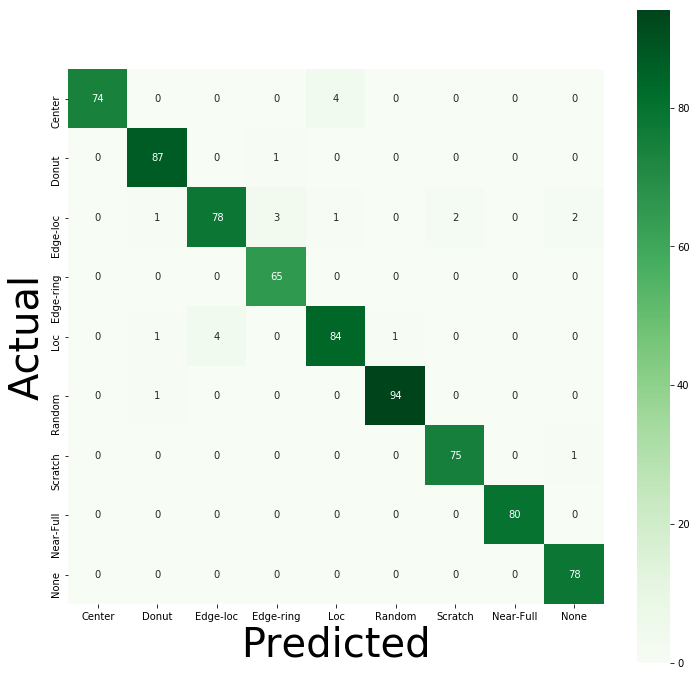

In [ ]:
Y_pred = model.predict(X_val)

Y_pred = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(12, 12))
ax = sns.heatmap(cm, cmap=plt.cm.Greens, annot=True, square=True, xticklabels=defect_types, yticklabels=defect_types)
ax.set_ylabel('Actual', fontsize=40)
ax.set_xlabel('Predicted', fontsize=40)

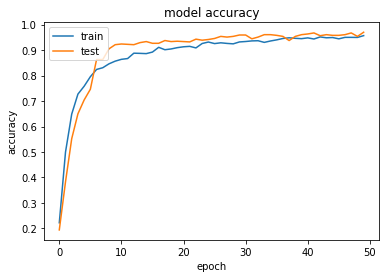

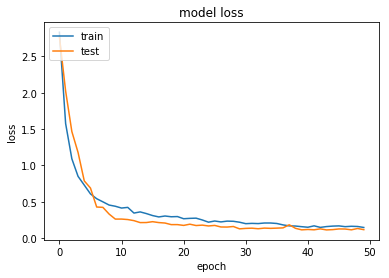

In [ ]:
# accuracy plot 
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# loss plot
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Testing By External Images

[2.6362535e-04 7.1135517e-05 9.6175331e-04 1.1398074e-03 2.2580383e-04
 2.7196391e-02 8.9996010e-02 8.7870312e-01 1.4422992e-03]


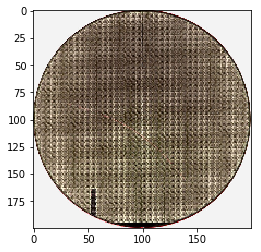

Prediction: Near-Full


In [ ]:
from skimage import io
from keras.preprocessing import image
#path='imbalanced/Scratch/Scratch_400.jpg'
img = image.load_img('../input/wafermap/WaferMap/test/wafermapdefects.jpg', grayscale=False, target_size=(64, 64))
show_img=image.load_img('../input/wafermap/WaferMap/test/wafermapdefects.jpg', grayscale=False, target_size=(200, 200))
defect_class = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-Full','None']
x = image.img_to_array(img)
x = np.expand_dims(x, axis = 0)

x /= 255

custom = model.predict(x)
print(custom[0])


x = np.array(x, 'float32')
#x = x.reshape([64, 64]);

#plt.gray()
plt.imshow(show_img)
plt.show()

a=custom[0]
max_num=max(a);
for i in range(0,len(a)):
    if a[i]==max_num:
        ind=i
        break
        
print('Prediction:',defect_class[ind])